# Phoenix Stellar Spectrum: Download, Convolve to R=100k, Save

1. Download raw PHOENIX HiRes spectrum (R≈500k) from the Göttingen server
2. Crop to 0.8–0.95 µm
3. Convolve with a Gaussian (FWHM = 1/R in ln λ) to properly degrade to R=100k
4. Resample onto a constant-R=100k grid (3 samples/resel)
5. Save to `Tellurics/Phoenix/high_res/`

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter1d

## 1. Configuration

In [3]:
# PHOENIX server
PHOENIX_BASE_URL  = "https://phoenix.astro.physik.uni-goettingen.de/data/HiResFITS"
PHOENIX_MODEL_GRID = "PHOENIX-ACES-AGSS-COND-2011"
PHOENIX_WAVE_FILE  = "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

# Stellar parameters
TEFF = 9600
LOGG = 4.0
FEH  = 0.0
LABEL = "A0V"

# Wavelength range (microns)
WMIN_NM = 800
WMAX_NM = 950

# Target resolution
R_TARGET = 100_000
SAMPLES_PER_RESEL = 3.0

FWHM_TO_SIGMA = 2.0 * np.sqrt(2.0 * np.log(2.0))

# Paths
PHOENIX_DIR  = Path("/home/mvasist/Documents/Tellurics/Phoenix")
DOWNLOAD_DIR = PHOENIX_DIR / "downloads"
OUTPUT_DIR   = PHOENIX_DIR / "high_res"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Teff={TEFF}, logg={LOGG}, [Fe/H]={FEH}")
print(f"Range: {WMIN_NM}–{WMAX_NM} µm")
print(f"R_target: {R_TARGET:,}, {SAMPLES_PER_RESEL:g} samples/resel")

Teff=9600, logg=4.0, [Fe/H]=0.0
Range: 800–950 µm
R_target: 100,000, 3 samples/resel


## 2. Download the raw PHOENIX data

In [4]:
def download_if_needed(url, output_path):
    if output_path.exists():
        print(f"Already exists: {output_path}")
        return
    print(f"Downloading: {url}")
    urlretrieve(url, output_path)
    print(f"Saved: {output_path}")

In [5]:
# Metallicity string for PHOENIX file naming
# For solar metallicity PHOENIX uses 'Z-0.0'
if FEH == 0.0:
    z_folder, z_file = "Z-0.0", "-0.0"
elif FEH > 0:
    z_folder = f"Z+{abs(FEH):.1f}"
    z_file = f"+{abs(FEH):.1f}"
else:
    z_folder = f"Z-{abs(FEH):.1f}"
    z_file = f"-{abs(FEH):.1f}"

# Download wavelength grid
wave_url  = f"{PHOENIX_BASE_URL}/{PHOENIX_WAVE_FILE}"
wave_file = DOWNLOAD_DIR / PHOENIX_WAVE_FILE
download_if_needed(wave_url, wave_file)

# Download spectrum
spectrum_name = f"lte{TEFF:05d}-{LOGG:.2f}{z_file}.{PHOENIX_MODEL_GRID}-HiRes.fits"
spectrum_url  = f"{PHOENIX_BASE_URL}/{PHOENIX_MODEL_GRID}/{z_folder}/{spectrum_name}"
spectrum_file = DOWNLOAD_DIR / spectrum_name
download_if_needed(spectrum_url, spectrum_file)

Already exists: /home/mvasist/Documents/Tellurics/Phoenix/downloads/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits
Already exists: /home/mvasist/Documents/Tellurics/Phoenix/downloads/lte09600-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


## 3. Load and crop to 0.8–0.95 µm

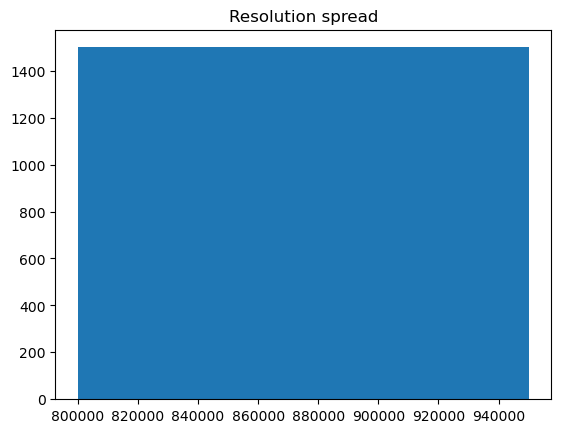

Raw PHOENIX cropped to 800–950 nm
  Points    : 150001
  Sampling R: 875,000
  Range (nm): 800.0000 – 950.0000


In [6]:
# Load raw PHOENIX data
wave_angstrom = fits.getdata(wave_file)
flux_raw      = fits.getdata(spectrum_file)
wave_nm_raw   = wave_angstrom * 1e-1  # Å → nm

# Crop to range
cut = (wave_nm_raw >= WMIN_NM) & (wave_nm_raw <= WMAX_NM)
wave_nm  = np.asarray(wave_nm_raw[cut], dtype=np.float64)
flux_raw_cut = np.asarray(flux_raw[cut], dtype=np.float64)

# Clean NaNs
good = np.isfinite(wave_nm) & np.isfinite(flux_raw_cut)
wave_nm = wave_nm[good]
flux_raw_cut = flux_raw_cut[good]


# Check native R
dlog_native = np.diff(np.log(wave_nm))
R_native = 1.0 / np.median(dlog_native)

plt.title("Resolution spread")
plt.hist(1.0/dlog_native, bins=100)
plt.show()

print(f"Raw PHOENIX cropped to {WMIN_NM}–{WMAX_NM} nm")
print(f"  Points    : {len(wave_nm)}")
print(f"  Sampling R: {R_native:,.0f}")
print(f"  Range (nm): {wave_nm[0]:.4f} – {wave_nm[-1]:.4f}")

## 4. Convolve to R=100k and resample

1. Interpolate onto a uniform ln(λ) grid (native PHOENIX isn't perfectly log-spaced)
2. Apply Gaussian with FWHM = 1/R in ln(λ)
3. Resample onto the constant-R=100k output grid

In [7]:
# Step 1: uniform ln(λ) grid at native sampling
log_native = np.log(wave_nm) 
dlog = float(np.median(np.diff(log_native)))
print(f"  R_native : {1/dlog:,.3f}")

log_uniform = np.arange(log_native[0], log_native[-1] + 0.5 * dlog, dlog) #(1/800k, 1/(950k + 875k/2), 1/875k)
print(log_uniform)
flux_uniform = np.interp(log_uniform, log_native, flux_raw_cut)

# Step 2: Gaussian convolution
sigma_log = 1.0 / (R_TARGET * FWHM_TO_SIGMA)
sigma_pixels = sigma_log / dlog

print(f"Convolution parameters:")
print(f"  FWHM in ln(λ) : {1.0/R_TARGET:.2e}")
print(f"  σ in ln(λ)     : {sigma_log:.2e}")
print(f"  σ in pixels    : {sigma_pixels:.2f}")
print(f"  Uniform grid   : {len(log_uniform)} points, dlog={dlog:.2e}")

flux_convolved = gaussian_filter1d(flux_uniform, sigma=sigma_pixels, mode="nearest", truncate=4.0)

# Step 3: build R=100k output grid and resample
n_out = int(np.ceil(np.log(WMAX_NM / WMIN_NM) * R_TARGET * SAMPLES_PER_RESEL))
wave_out_nm = np.geomspace(WMIN_NM, WMAX_NM, n_out + 1)

flux_out = np.interp(np.log(wave_out_nm), log_uniform, flux_convolved)

# Verify output R
R_out = 1.0 / np.median(np.diff(np.log(wave_out_nm)))

print(f"\nOutput grid:")
print(f"  Points      : {len(wave_out_nm)}")
print(f"  Sampling R  : {R_out:,.0f}")
print(f"  Resolving R : {R_out / SAMPLES_PER_RESEL:,.0f}")

  R_native : 875,000.000
[6.68461173 6.68461287 6.68461401 ... 6.85645973 6.85646087 6.85646201]
Convolution parameters:
  FWHM in ln(λ) : 1.00e-05
  σ in ln(λ)     : 4.25e-06
  σ in pixels    : 3.72
  Uniform grid   : 150370 points, dlog=1.14e-06

Output grid:
  Points      : 51557
  Sampling R  : 300,005
  Resolving R : 100,002


## 5. Plot: raw vs convolved

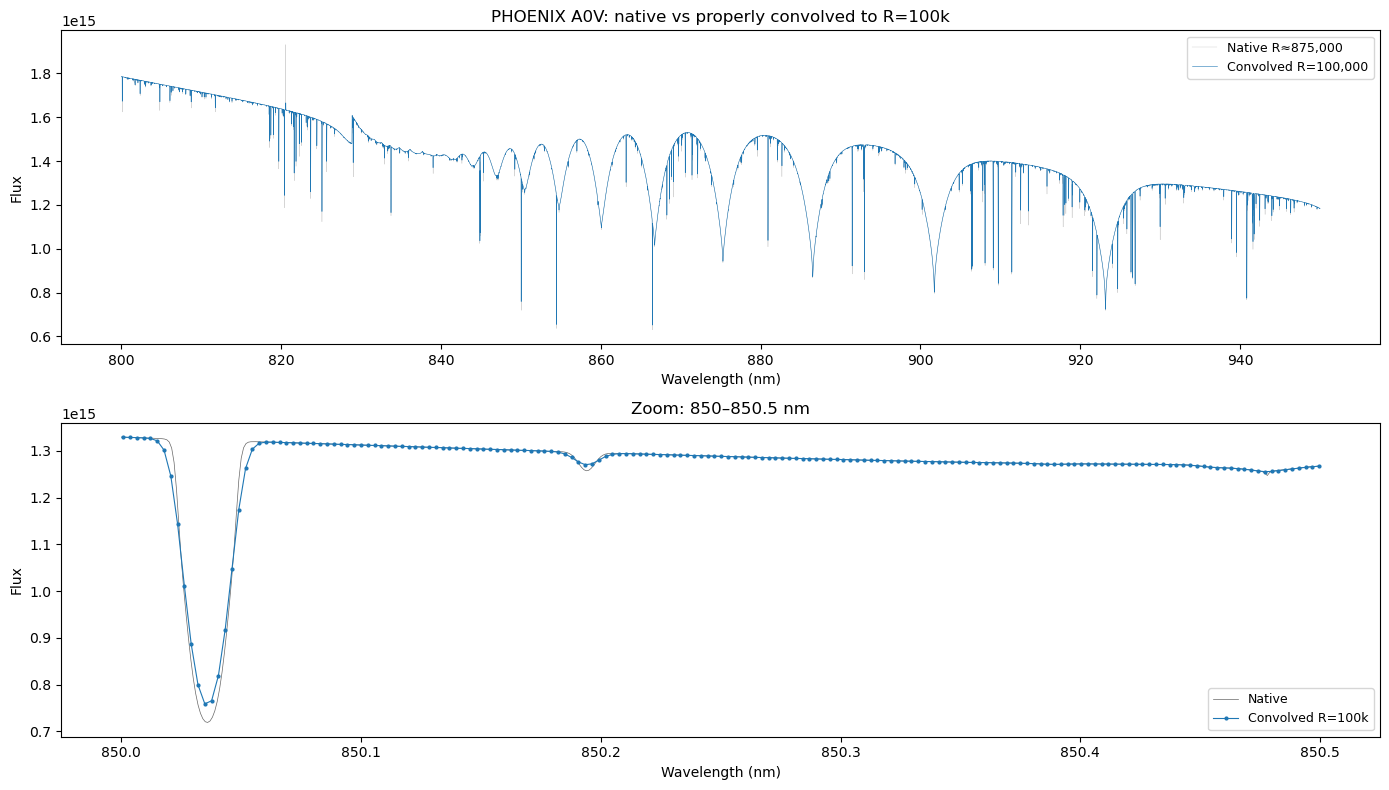

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full range
ax = axes[0]
ax.plot(wave_nm, flux_raw_cut, 'k', lw=0.15, alpha=0.4, label=f'Native R≈{R_native:,.0f}')
ax.plot(wave_out_nm, flux_out, 'C0', lw=0.4, label=f'Convolved R={R_TARGET:,}')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Flux')
ax.set_title('PHOENIX A0V: native vs properly convolved to R=100k')
ax.legend(fontsize=9)

# Zoom
ax = axes[1]
zn = (wave_nm >= 850) & (wave_nm <= 850.5)
zo = (wave_out_nm >= 850) & (wave_out_nm <= 850.5)
ax.plot(wave_nm[zn], flux_raw_cut[zn], 'k', lw=0.5, alpha=0.6, label='Native')
ax.plot(wave_out_nm[zo], flux_out[zo], 'C0o-', ms=2, lw=0.8, label='Convolved R=100k')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Flux')
ax.set_title('Zoom: 850–850.5 nm')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Save to FITS

In [16]:
output_fits = OUTPUT_DIR / f"phoenix_{LABEL}_T{TEFF}_logg{LOGG:.1f}_feh{FEH:+.1f}_R{R_TARGET}_s{SAMPLES_PER_RESEL:g}_convolved.fits"

columns = [
    fits.Column(name="WAVE_NANO", array=wave_out_nm.astype("float64"), format="D"),
    fits.Column(name="FLUX", array=flux_out.astype("float32"), format="E"),
]

hdu = fits.BinTableHDU.from_columns(columns)
hdu.name = "SPECTRUM"
hdu.header["LABEL"]   = LABEL
hdu.header["TEFF"]    = TEFF
hdu.header["LOGG"]    = LOGG
hdu.header["FEH"]     = FEH
hdu.header["WMIN"]    = WMIN_NM
hdu.header["WMAX"]    = WMAX_NM
hdu.header["R"]       = R_TARGET
hdu.header["SPRES"]   = SAMPLES_PER_RESEL
hdu.header["NPOINTS"] = len(wave_out_nm)
hdu.header["SRC"]     = "PHOENIX-HiRes"
hdu.header["COMMENT"] = f"Convolved from R~{R_native:.0f} to R={R_TARGET} with Gaussian in ln(lam)"

primary = fits.PrimaryHDU()
primary.header["OBJECT"] = f"{LABEL}_T{TEFF}"

fits.HDUList([primary, hdu]).writeto(output_fits, overwrite=True)

print(f"Saved: {output_fits}")
print(f"Size : {output_fits.stat().st_size / 1024:.1f} KB")
print(f"Points: {len(wave_out_nm)}")

Saved: /home/mvasist/Documents/Tellurics/Phoenix/high_res/phoenix_A0V_T9600_logg4.0_feh+0.0_R100000_s3_convolved.fits
Size : 610.3 KB
Points: 51557


## 7. Verify

In [18]:
with fits.open(output_fits) as hdul:
    hdul.info()
    d = hdul['SPECTRUM'].data
    h = hdul['SPECTRUM'].header

print(f"\nRange   : {d['WAVE_NANO'][0]:.6f} – {d['WAVE_NANO'][-1]:.6f} nm")
print(f"Points  : {len(d['WAVE_NANO'])}")
print(f"R       : {h['R']}")
print(f"Comment : {h['COMMENT']}")

Filename: /home/mvasist/Documents/Tellurics/Phoenix/high_res/phoenix_A0V_T9600_logg4.0_feh+0.0_R100000_s3_convolved.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  SPECTRUM      1 BinTableHDU     24   51557R x 2C   [D, E]   

Range   : 800.000000 – 950.000000 nm
Points  : 51557
R       : 100000
Comment : Convolved from R~875000 to R=100000 with Gaussian in ln(lam)
